## Mecánica del vuelo - Tarea N°1: Aerodinámica

### Datos simulados

In [6]:
with open('data_f22.csv', 'r') as archivo:
    lineas = [line.rstrip() for line in archivo]

v_indicated = [] # [knot]
v_true = []      # [knot]
pressure = []    # [Pa]
temperature = [] # [°C]
rho = []         # [kg/m3]
altitude = []    # [km]
lightspeed = []  # [m/s]


for i in lineas[1:-1]:
    v_indicated.append(float(i.split(',')[1]))
    v_true.append(float(i.split(',')[2]))
    pressure.append(float(i.split(',')[14])* 0.491154 * 6894.76)
    temperature.append(float(i.split(',')[15]))
    rho.append(float(i.split(',')[17]) * 1.225)
    altitude.append(float(i.split(',')[31]) * 0.3048 / 1000)
    lightspeed.append((1.4 * 287.0528 * (float(i.split(',')[15]) + 273.15))**.5)

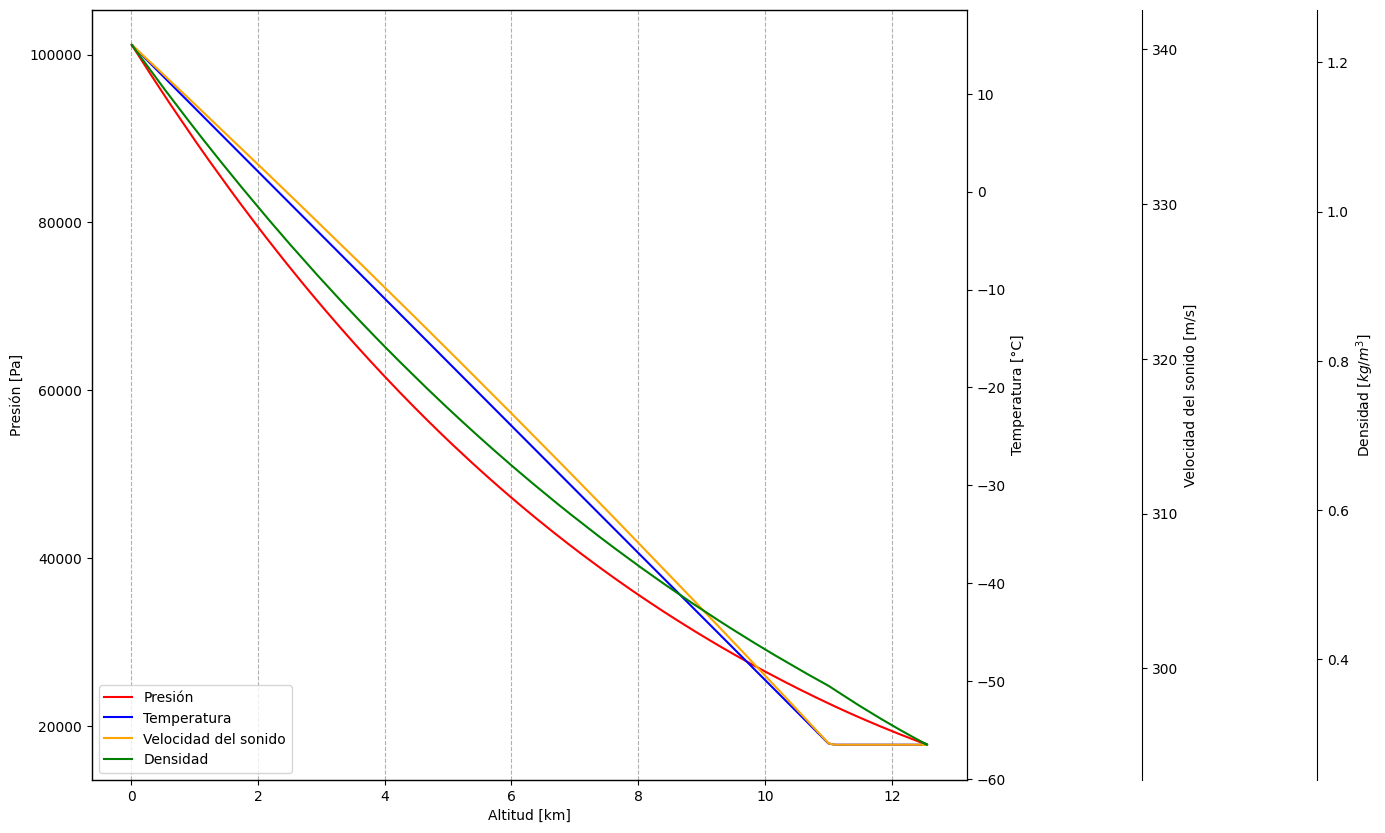

In [55]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax1 = plt.subplots()
fig.subplots_adjust(right=0.75) 
plt.rcParams['figure.figsize'] = (14,8)

ax2 = ax1.twinx()

ax3 = ax1.twinx()
ax3.spines.right.set_position(("axes", 1.20))

ax4 = ax1.twinx()
ax4.spines.right.set_position(("axes", 1.40))

p1, = ax1.plot(altitude, pressure, color='red', label="Presión")
p2, = ax2.plot(altitude, temperature, color='blue', label="Temperatura")
p3, = ax3.plot(altitude, lightspeed, color='orange', label="Velocidad del sonido")
p4, = ax4.plot(altitude, rho, color='green', label = 'Densidad')

ax1.set_xlabel("Altitud [km]")
ax1.set_ylabel("Presión [Pa]")
ax1.tick_params(axis='y')

ax2.set_ylabel("Temperatura [°C]")
ax2.tick_params(axis='y')

ax3.set_ylabel("Velocidad del sonido [m/s]")
ax3.tick_params(axis='y')

ax4.set_ylabel("Densidad $[kg/m^3]$")
ax4.tick_params(axis='y')

lines = [p1, p2, p3, p4]
ax1.legend(lines, [l.get_label() for l in lines], loc="lower left")


ax1.grid(linestyle='--', axis='x')
plt.show()


In [59]:
def T(Z):
    if Z<=11: return 15 - 6.5 * Z
    else: return T(11)

def P(Z):
    if Z<=11:
        return 101300 * ((T(Z)+273.15)/288.15)**(9.807/(287*6.5/1000))
    else:
        return P(11) * np.exp(1)**(-9.807 * (Z-11) / (287 * (T(11)+273.15)))

def a(Z): return (1.4 * 287 * (T(Z) + 287))**.5

def rho_air(Z): return P(Z)/(287 * (T(Z)+273.15))

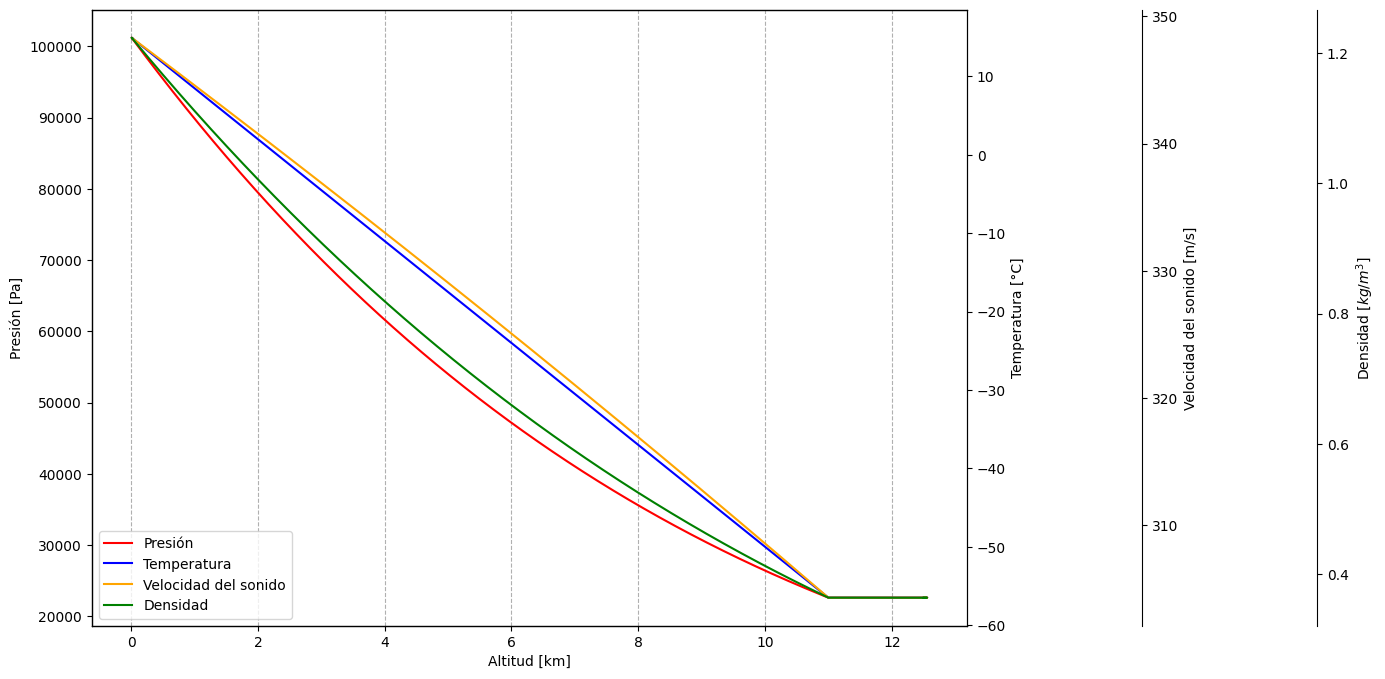

In [60]:
fig, ax1 = plt.subplots()
fig.subplots_adjust(right=0.75) 
plt.rcParams['figure.figsize'] = (14,8)

ax2 = ax1.twinx()

ax3 = ax1.twinx()
ax3.spines.right.set_position(("axes", 1.20))

ax4 = ax1.twinx()
ax4.spines.right.set_position(("axes", 1.40))

p1, = ax1.plot(altitude, [P(z) for z in altitude], color='red', label="Presión")
p2, = ax2.plot(altitude, [T(z) for z in altitude], color='blue', label="Temperatura")
p3, = ax3.plot(altitude, [a(z) for z in altitude], color='orange', label="Velocidad del sonido")
p4, = ax4.plot(altitude, [rho_air(z) for z in altitude], color='green', label = 'Densidad')

ax1.set_xlabel("Altitud [km]")
ax1.set_ylabel("Presión [Pa]")
ax1.tick_params(axis='y')

ax2.set_ylabel("Temperatura [°C]")
ax2.tick_params(axis='y')

ax3.set_ylabel("Velocidad del sonido [m/s]")
ax3.tick_params(axis='y')

ax4.set_ylabel("Densidad $[kg/m^3]$")
ax4.tick_params(axis='y')

lines = [p1, p2, p3, p4]
ax1.legend(lines, [l.get_label() for l in lines], loc="lower left")


ax1.grid(linestyle='--', axis='x')
plt.show()